In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d, griddata
from itertools import product
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
import glob

defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution
pd.set_option('display.max_rows', 200)

In [2]:
cmsCutflow = pd.read_pickle('../../CMS-EXO-20-004/AuxInfo/CMS-EXO-20-004-data/DMsimp_S3D_uR_CF_Monojet.pcl')

In [3]:
cutflow = pd.read_pickle('../../t-channel/DMSimp_S3D_uR_1j_CMS-BPs_v2/Events/run_01/scanResults_2j.pcl')

In [4]:
cutflow.T

,0,1,2,3,4,5,6,7,8,9,...,134,135,136,137,138,139,140,141,142,143
Coupling,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,...,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel
Mode,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,...,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets
$m_{med}$,100.0,100.0,100.0,100.0,100.0,100.0,300.0,300.0,300.0,300.0,...,2000.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0
$m_{DM}$,1.0,1.0,1.0,75.0,75.0,75.0,1.0,1.0,1.0,200.0,...,500.0,1.0,1.0,1.0,200.0,200.0,200.0,350.0,350.0,350.0
Data-takingperiod,2018,2017,2016,2018,2017,2016,2018,2017,2016,2018,...,2016,2018,2017,2016,2018,2017,2016,2018,2017,2016
Luminosity (1/fb),59.7,41.5,36.0,59.7,41.5,36.0,59.7,41.5,36.0,59.7,...,36.0,59.7,41.5,36.0,59.7,41.5,36.0,59.7,41.5,36.0
bin_250.0_280.0,34717.380464,34717.380464,29757.754683,34257.283229,38824.920993,36541.102111,22020.211834,18790.327441,16700.402245,3909.120881,...,0.006948,0.001999,0.002077,0.002519,0.002641,0.002184,0.002006,0.002358,0.00282,0.001751
bin_250.0_280.0_ErrorPlus,9278.610219,9278.610219,8590.323838,8845.192496,9416.42648,9135.275528,647.37238,597.497651,563.290587,245.280059,...,0.000651,0.000234,0.000232,0.000256,0.000259,0.000238,0.000226,0.000244,0.000262,0.000209
bin_250.0_280.0_ErrorMinus,9278.610219,9278.610219,8590.323838,8845.192496,9416.42648,9135.275528,647.37238,597.497651,563.290587,245.280059,...,0.000651,0.000234,0.000232,0.000256,0.000259,0.000238,0.000226,0.000244,0.000262,0.000209
bin_280.0_310.0,17358.690232,19838.503122,17358.690232,20554.369938,22838.18882,15986.732174,15199.455968,12976.535533,10924.608977,2477.82859,...,0.007558,0.003349,0.002726,0.002389,0.003327,0.00254,0.002413,0.003355,0.002553,0.002407


In [5]:
cmsCutflow.T

,0,1,2,3,4,5,6,7,8,9,...,171,172,173,174,175,176,177,178,179,180
$m_{med}$,1000.0,300.0,1000.0,1800.0,1000.0,1000.0,1800.0,1400.0,1400.0,1400.0,...,1800.0,300.0,1200.0,1600.0,1000.0,1200.0,2000.0,1600.0,1200.0,1200.0
$m_{DM}$,400.0,1.0,400.0,1.0,600.0,600.0,1.0,1.0,200.0,1.0,...,1.0,200.0,750.0,500.0,1.0,1.0,500.0,800.0,900.0,750.0
$\lambda$,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Mode,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+QCDjets,DM+2QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+2QCDjets,...,DM+QCDjets,DM+QCDjets,DM+2QCDjets,DM+2QCDjets,DM+QCDjets,DM+QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets
Data-takingperiod,2017,2017,2018,2017,2017,2017,2018,2018,2017,2018,...,2017,2017,2018,2017,2018,2018,2018,2018,2017,2017
Fullsample,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Triggeremulation,0.90814,0.5588,0.90293,0.79897,0.93701,0.89098,0.98727,0.97933,0.98015,0.84539,...,0.9875,0.51669,0.89866,0.89838,0.96315,0.97395,0.84466,0.91676,0.86735,0.90544
$p_{T}^{miss}>250$GeV,0.72881,0.16807,0.72742,0.59405,0.77029,0.65109,0.95136,0.92475,0.92408,0.69336,...,0.95202,0.096462,0.70554,0.75958,0.86484,0.90216,0.68149,0.79855,0.58777,0.70809
$p_{T}^{miss}$qualityfilters,0.72671,0.16768,0.72562,0.59091,0.76717,0.64939,0.94169,0.91721,0.91589,0.69071,...,0.94073,0.096312,0.70405,0.75624,0.86041,0.89633,0.67874,0.79572,0.58629,0.70639
Electronveto,0.72431,0.1672,0.72357,0.58882,0.76191,0.64746,0.93593,0.91134,0.90961,0.68863,...,0.93456,0.09546,0.70199,0.7535,0.85541,0.89079,0.67642,0.79316,0.58398,0.70373


In [6]:
year = 2017

cutflow = cutflow[cutflow['Data-takingperiod']==year]
cmsCutflow = cmsCutflow[(cmsCutflow['Data-takingperiod']==year)&(cmsCutflow['Mode']=='DM+2QCDjets')]


In [7]:
cmsCutflow.T

,0,1,3,5,11,12,18,19,26,29,...,124,127,129,135,140,141,157,174,179,180
$m_{med}$,1000.0,300.0,1800.0,1000.0,1000.0,1400.0,1000.0,1800.0,500.0,100.0,...,750.0,1400.0,1600.0,750.0,750.0,1400.0,1600.0,1600.0,1200.0,1200.0
$m_{DM}$,400.0,1.0,1.0,600.0,1.0,500.0,750.0,200.0,1.0,75.0,...,1.0,800.0,350.0,550.0,700.0,200.0,200.0,500.0,900.0,750.0
$\lambda$,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Mode,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,...,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets
Data-takingperiod,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,...,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017
Fullsample,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Triggeremulation,0.90814,0.5588,0.79897,0.89098,0.882,0.9109,0.83283,0.82011,0.78855,0.22066,...,0.86881,0.92136,0.87683,0.7745,0.45324,0.86765,0.84687,0.89838,0.86735,0.90544
$p_{T}^{miss}>250$GeV,0.72881,0.16807,0.59405,0.65109,0.70494,0.77601,0.50678,0.60917,0.39512,0.075977,...,0.62345,0.77449,0.71757,0.40654,0.24491,0.69731,0.65944,0.75958,0.58777,0.70809
$p_{T}^{miss}$qualityfilters,0.72671,0.16768,0.59091,0.64939,0.70299,0.7728,0.50558,0.60639,0.39447,0.075829,...,0.62203,0.77192,0.71411,0.40569,0.24426,0.69468,0.65661,0.75624,0.58629,0.70639
Electronveto,0.72431,0.1672,0.58882,0.64746,0.70052,0.77004,0.50357,0.604,0.39346,0.075346,...,0.62023,0.76904,0.71176,0.40422,0.24268,0.69241,0.65439,0.7535,0.58398,0.70373


In [8]:
pd.read_pickle('../DMSimp_S3D_uR_2j_CMS-BPs_sample/Events/run_02/ys3u1_300_200_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,2842.506283,3180.534057,4133.157784
bin_250.0_280.0_ErrorPlus,208.985218,221.062398,252.003078
bin_250.0_280.0_ErrorMinus,208.985218,221.062398,252.003078
bin_280.0_310.0,1982.071949,1951.342151,2089.62624
bin_280.0_310.0_ErrorPlus,174.511704,174.511704,179.183972
bin_280.0_310.0_ErrorMinus,174.511704,174.511704,179.183972
bin_310.0_340.0,1106.272715,1459.665388,1690.138871
bin_310.0_340.0_ErrorPlus,130.37549,149.758509,161.148418


In [9]:
abs(0.16836-0.04292)/0.16836

0.7450700879068661

In [10]:
pd.read_pickle('../DMSimp_S3D_uR_2j_CMS-BPs_sample/Events/run_03/ys3u1_500_200_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,1104.141753,1225.111097,1464.677836
bin_250.0_280.0_ErrorPlus,36.186784,38.117579,41.678169
bin_250.0_280.0_ErrorMinus,36.186784,38.117579,41.678169
bin_280.0_310.0,1034.16929,1202.577592,1394.705373
bin_280.0_310.0_ErrorPlus,35.06153,37.765404,40.670435
bin_280.0_310.0_ErrorMinus,35.06153,37.765404,40.670435
bin_310.0_340.0,990.288254,1153.952659,1242.900706
bin_310.0_340.0_ErrorPlus,34.352325,37.032025,38.393331


In [11]:
abs(0.31071-0.398878)/0.31071

0.2837629944321072

In [12]:
models = []
mCols = ['$m_{med}$','$m_{DM}$','$\lambda$','Data-takingperiod']
for row in cutflow[mCols].values:
    m = dict(zip(mCols,row.tolist()))
    if m not in models:
        models.append(m)
print('%i models loaded' %len(models))

48 models loaded


In [13]:
parameters = {label : list(set([m[label] for m in models])) for label in mCols}
for k,v in parameters.items():
    if len(v) == 1:
        parameters[k] = v[0]
print(parameters)

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in parameters.items() if k not in ['$m_{med}$','$m_{DM}$']])
print(textstr)

{'$m_{med}$': [1600.0, 100.0, 1000.0, 1800.0, 300.0, 750.0, 1200.0, 2000.0, 500.0, 1400.0, 2200.0], '$m_{DM}$': [800.0, 1.0, 900.0, 550.0, 200.0, 650.0, 75.0, 750.0, 400.0, 500.0, 600.0, 700.0, 350.0], '$\\lambda$': 1.0, 'Data-takingperiod': 2017.0}
$\lambda$ = 1.0
Data-takingperiod = 2017.0


In [14]:
keys = list(cmsCutflow[mCols].columns.values)
i1 = cutflow.set_index(keys).index
i2 = cmsCutflow.set_index(keys).index
cutflow = cutflow[i1.isin(i2)]
cmsCutflow = cmsCutflow[i2.isin(i1)]
print(len(cutflow),len(cmsCutflow))

46 46


In [15]:
cutflow.sort_values(['$m_{med}$','$m_{DM}$'],inplace=True,
                ascending=[True,True],ignore_index=True)  
cmsCutflow.sort_values(['$m_{med}$','$m_{DM}$'],inplace=True,
                ascending=[True,True],ignore_index=True)

In [16]:
cutflow.T

,0,1,2,3,4,5,6,7,8,9,...,36,37,38,39,40,41,42,43,44,45
Coupling,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,...,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel
Mode,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,...,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets
$m_{med}$,100.0,100.0,300.0,300.0,500.0,500.0,500.0,750.0,750.0,750.0,...,1800.0,1800.0,1800.0,1800.0,1800.0,2000.0,2000.0,2000.0,2200.0,2200.0
$m_{DM}$,1.0,75.0,1.0,200.0,1.0,200.0,400.0,1.0,200.0,400.0,...,1.0,200.0,350.0,500.0,650.0,1.0,350.0,500.0,1.0,200.0
Data-takingperiod,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,...,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017
Luminosity (1/fb),41.5,41.5,41.5,41.5,41.5,41.5,41.5,41.5,41.5,41.5,...,41.5,41.5,41.5,41.5,41.5,41.5,41.5,41.5,41.5,41.5
bin_250.0_280.0,34717.380464,38824.920993,18790.327441,2816.413863,1315.741987,1245.167444,318.661078,80.581328,70.62523,85.238734,...,0.026922,0.026279,0.026576,0.024005,0.027176,0.008067,0.007396,0.007863,0.002077,0.002184
bin_250.0_280.0_ErrorPlus,9278.610219,9416.42648,597.497651,208.195304,43.26133,38.426702,17.621998,3.372224,2.963369,2.937513,...,0.002317,0.002253,0.002214,0.002021,0.002043,0.000756,0.000702,0.000692,0.000232,0.000238
bin_250.0_280.0_ErrorMinus,9278.610219,9416.42648,597.497651,208.195304,43.26133,38.426702,17.621998,3.372224,2.963369,2.937513,...,0.002317,0.002253,0.002214,0.002021,0.002043,0.000756,0.000702,0.000692,0.000232,0.000238
bin_280.0_310.0,19838.503122,22838.18882,12976.535533,1923.779961,1362.681972,1169.271523,254.344163,86.226255,77.836961,86.45066,...,0.032705,0.024734,0.030398,0.029377,0.02672,0.008138,0.007462,0.008716,0.002726,0.00254


In [17]:
cmsCutflow.T

,0,1,2,3,4,5,6,7,8,9,...,36,37,38,39,40,41,42,43,44,45
$m_{med}$,100.0,100.0,300.0,300.0,500.0,500.0,500.0,750.0,750.0,750.0,...,1800.0,1800.0,1800.0,1800.0,1800.0,2000.0,2000.0,2000.0,2200.0,2200.0
$m_{DM}$,1.0,75.0,1.0,200.0,1.0,200.0,400.0,1.0,200.0,400.0,...,1.0,200.0,350.0,500.0,650.0,1.0,350.0,500.0,1.0,200.0
$\lambda$,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Mode,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,...,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets
Data-takingperiod,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,...,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017
Fullsample,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Triggeremulation,0.12259,0.22066,0.5588,0.60136,0.78855,0.7855,0.65513,0.86881,0.88265,0.85896,...,0.79897,0.82011,0.85555,0.87751,0.89749,0.78041,0.83202,0.85823,0.74639,0.77777
$p_{T}^{miss}>250$GeV,0.028567,0.075977,0.16807,0.21455,0.39512,0.39029,0.2787,0.62345,0.63913,0.55841,...,0.59405,0.60917,0.67584,0.72289,0.76014,0.56533,0.62899,0.6819,0.50435,0.52241
$p_{T}^{miss}$qualityfilters,0.028531,0.075829,0.16768,0.21423,0.39447,0.38955,0.27808,0.62203,0.63786,0.55747,...,0.59091,0.60639,0.67249,0.71939,0.75595,0.56199,0.62604,0.6783,0.50158,0.52016
Electronveto,0.028406,0.075346,0.1672,0.21355,0.39346,0.38846,0.27688,0.62023,0.63609,0.55559,...,0.58882,0.604,0.67052,0.71664,0.75347,0.56005,0.62401,0.67584,0.49979,0.51868


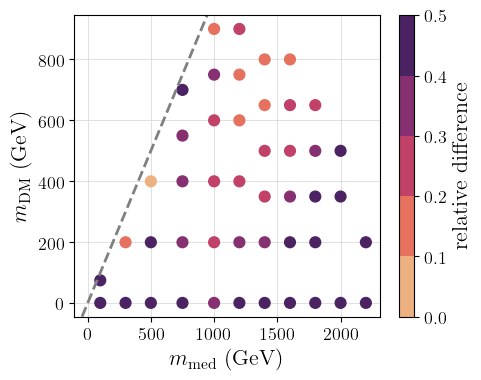

In [18]:
mmed = cutflow['$m_{med}$']
mDM = cutflow['$m_{DM}$']

relDiff = np.abs(cmsCutflow['HCALmitigation($\\phi^{miss}$)'] - cutflow['HCALmitigation($\\phi^{miss}$)'])/np.array(cmsCutflow['HCALmitigation($\\phi^{miss}$)'])

plt.scatter(x=mmed, y=mDM, c=relDiff, cmap=plt.get_cmap('flare', 5), vmin=0., vmax=0.5, s=60)
cbar = plt.colorbar(label=r'relative difference')
cbar.set_ticks([0.,0.1,0.2,0.3,0.4,0.5])
plt.axline((1, 1), slope=1, linestyle='--', color='gray')

plt.xlabel(r'$m_{\rm med}$ (GeV)')
plt.ylabel(r'$m_{\rm DM}$ (GeV)')

plt.tight_layout()
# plt.savefig('relDiff_eff_2j_default.png')

plt.show()

In [39]:
cutflow[(cutflow['$m_{med}$']==1000)&(cutflow['$m_{DM}$']==900)].T

,17
Coupling,tchannel
Mode,DM+QCDjets
$m_{med}$,1000.0
$m_{DM}$,900.0
Data-takingperiod,2017
Luminosity (1/fb),41.5
bin_250.0_280.0,7.086368
bin_250.0_280.0_ErrorPlus,0.254059
bin_250.0_280.0_ErrorMinus,0.254059
bin_280.0_310.0,6.02068


In [41]:
cmsCutflow[(cutflow['$m_{med}$']==100)&(cutflow['$m_{DM}$']==1)].T

,0
$m_{med}$,100.0
$m_{DM}$,1.0
$\lambda$,1.0
Mode,DM+QCDjets
Data-takingperiod,2017
Fullsample,1.0
Triggeremulation,0.047334
$p_{T}^{miss}>250$GeV,0.003092
$p_{T}^{miss}$qualityfilters,0.003092
Electronveto,0.003073


In [18]:
cutflow[(cutflow['$m_{med}$']==1800)&(cutflow['$m_{DM}$']==1)].T

,36
Coupling,tchannel
Mode,DM+QCDjets
$m_{med}$,1800.0
$m_{DM}$,1.0
Data-takingperiod,2017
Luminosity (1/fb),41.5
bin_250.0_280.0,7.812074
bin_250.0_280.0_ErrorPlus,0.36424
bin_250.0_280.0_ErrorMinus,0.36424
bin_280.0_310.0,6.470435
